In [18]:
# import libraries
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Keras 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Conv1D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load dataset
data = pd.read_csv('dataset.csv')

In [4]:
dataset = data.copy()

In [5]:
dataset.head()

,id,pub_title,dataset_label,full_text
0,d0fa7568-7d8e-4db9-870f-f9c6f668c17b,The Impact of Dual Enrollment on College Degre...,national education longitudinal study,what is this study about this study used data ...
1,2f26f645-3dec-485d-b68d-f013c9e05e60,Educational Attainment of High School Dropouts...,national education longitudinal study,november 2004 dropping out of high school is n...
2,c5d5cd2c-59de-4f29-bbb1-6a88c7b52f29,Differences in Outcomes for Female and Male St...,national education longitudinal study,differences in outcomes for female and male st...
3,5c9a3bc9-41ba-4574-ad71-e25c1442c8af,Stepping Stone and Option Value in a Model of ...,national education longitudinal study,abstract federal reserve bank of richmond s1 a...
4,c754dec7-c5a3-4337-9892-c02158475064,"Parental Effort, School Resources, and Student...",national education longitudinal study,abstract this article investigates an importan...


In [6]:
dataset['dataset_label'].value_counts()

dataset_label
adni                                                                    3673
alzheimers disease neuroimaging initiative adni                         2400
trends in international mathematics and science study                   1163
baltimore longitudinal study of aging                                   1156
early childhood longitudinal study                                      1011
                                                                        ... 
national oceanic and atmospheric administration ccap                       1
national oceanic and atmospheric administration world ocean database       1
noaa international best track archive for climate stewardship              1
aging integrated database agid                                             1
cas covid19 antiviral candidate compounds data                             1
Name: count, Length: 130, dtype: int64

In [7]:
df = dataset.groupby('dataset_label').filter(lambda x: len(x) >= 4)

In [8]:
# Split into Train 80%, Validation 10%, Test 10%
X = df['full_text']
y = df['dataset_label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

In [9]:
# Tokenization 
num_words = 10000
tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [10]:
# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [11]:
# Padding sequences
max_len = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

In [12]:
# Encoding categorical labels
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

In [13]:
# Convert the integer-encoded labels into a binary class matrix
num_classes = len(le.classes_)

y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_val_cat   = to_categorical(y_val_enc,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test_enc,  num_classes=num_classes)

In [33]:
# GRU model
gru_model = Sequential(name="gru_model")
gru_model.add(Embedding(input_dim=num_words, output_dim=64))
gru_model.add(GRU(units=64, dropout=0.3, recurrent_dropout=0))
gru_model.add(Dense(y_train_cat.shape[1], activation='softmax'))

optimizer = Adam(learning_rate=0.0005) 

gru_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [34]:
# Train the model
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

history = gru_model.fit(
    X_train_pad, y_train_cat,
    batch_size=16,  
    epochs=10, 
    validation_data=(X_val_pad, y_val_cat),
    verbose=1,
    callbacks=[callback]
)

Epoch 1/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 62s 61ms/step - accuracy: 0.1705 - loss: 3.6080 - val_accuracy: 0.2372 - val_loss: 2.8198
Epoch 2/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.2570 - loss: 2.6491 - val_accuracy: 0.3010 - val_loss: 2.3950
Epoch 3/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 58s 59ms/step - accuracy: 0.3208 - loss: 2.2826 - val_accuracy: 0.3352 - val_loss: 2.1032
Epoch 4/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.3598 - loss: 2.0277 - val_accuracy: 0.3750 - val_loss: 1.9206
Epoch 5/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.4055 - loss: 1.8264 - val_accuracy: 0.3888 - val_loss: 1.8206
Epoch 6/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 60s 61ms/step - accuracy: 0.4331 - loss: 1.6852 - val_accuracy: 0.4153 - val_loss: 1.7323
Epoch 7/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 57s 58ms/step - accuracy: 0.4682 - loss: 1.5727 - val_accuracy: 0.4214 - val_loss: 1.6494
Epoch 8/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 56s 57ms/step - accuracy: 0.5012 - loss: 1.4566 - 

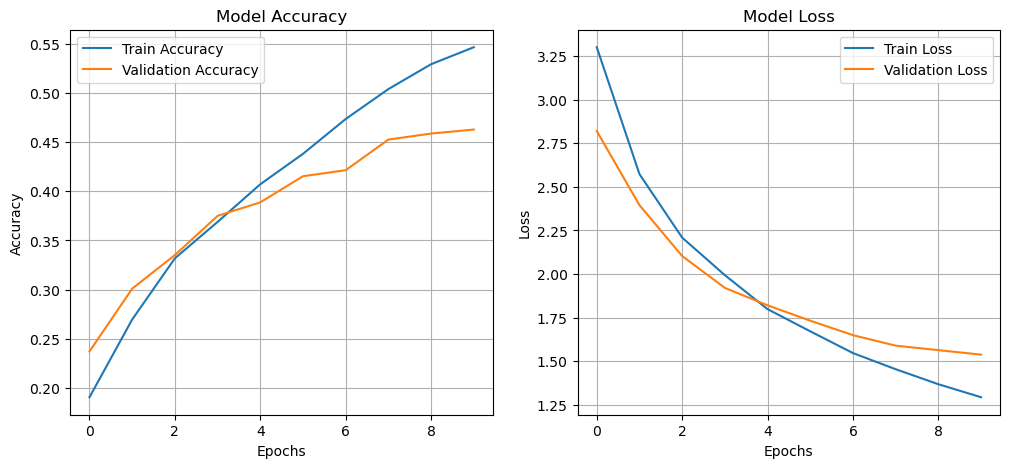

In [35]:
# Plot GRU model training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [36]:
# Evaluate the model on the test set
loss, accuracy = gru_model.evaluate(X_test_pad, y_test_cat, batch_size=32)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4764 - loss: 1.4913
Test Loss: 1.5306
Test Accuracy: 0.4661
